## Apresentação 5 - Cálculo Numérico
# ACOPLAMENTO HIDRÁULICO-MECÂNICO
**Grupo 1:** Bruno Lopes de Almeida Zuffo, 
João Victor Bozola Bosi, 
Lucas Antero Albuquerque, 
Matheus Marchi Baron, 
Natalia Yumi Watanabe, 
Victor Hugo Albertino e Silva.

---
## 1. Introdução e Parâmetros Iniciais
Neste capítulo, integramos o modelo da rede hidráulica com a membrana elástica (Gêmeo Digital completo). O sistema resolve de maneira monolítica as equações acopladas que governam a interação fluido-estrutura.

Abaixo definimos os parâmetros físicos e adimensionais da Seção 5.2.5 e iniciamos as instâncias isoladas antes do acoplamento.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
import os
import sys

# Configuração do path para importar os módulos locais
diretorio_atual = os.path.abspath('')
diretorio_pai = os.path.dirname(diretorio_atual)
if diretorio_pai not in sys.path:
    sys.path.insert(0, diretorio_pai)

from RedeHidraulica.functions import GeraGrafo, AssemblyVectorC, Assembly
from MembranaElastica.functionsM import BuildMatrizes_Eigen_Circular
from AcoplamentoHidraulicoMecanico.functionsHM import (
    Monta_Matriz_Global_Acoplada, Resolve_Passo_Tempo, Calcula_Matriz_R, 
    roda_exercicio_3, roda_exercicio_4, roda_exercicio_5
)

# ==============================================================================
# 1. PARÂMETROS FÍSICOS E ADIMENSIONAIS (Dados da Seção 5.2.5)
# ==============================================================================
# Rede Hidráulica
mu = 5e-4              # Pa.s
complex_level = 3
mm_to_m = 0.001
H_k = 1000e-6          # Largura do canal (ex: 1000 um)

# Membrana Elástica
R_fisico = 0.25e-2     # Raio físico: 0.25 cm em m
e_esp = 0.1e-3         # Espessura: 0.1 mm em m
sigma = 200.0          # Tensão: N/m
rho = 900.0            # Densidade: kg/m^3

# Parâmetros Adimensionais (Base)
Lx_ad, Ly_ad = 2.0, 2.0
R_ad = 1.0
sigma_ad = 1.0
rho_ad = 1.0
e_ad = 1.0
beta_ad = 0.1          # Fator de amortecimento

# Discretização e Simulação
Nx, Ny = 51, 51        # Malha base da membrana
h_ad = Lx_ad / (Nx - 1)
dt = 0.025             # Passo de tempo (adimensional)
t_max = 12.0           # Tempo final (adimensional)

p_inlet_dim = 10000.0  # Pressão de entrada (Pa)

# Definição dos nós de controle
n_inlet = 0
n_outlet = 5


---
## Exercício 1 — Esparsidade da Matriz de Amortecimento Hidráulico $R$

### Dedução de $R$

A terceira linha do sistema em blocos é a equação da rede:

$$\hat{h}^2 U v + \hat{A} p = f_p$$

Resolvendo para $p$ e substituindo na segunda linha (equação da membrana), o termo $-U^\top p$ produz:

$$-U^\top p = -U^\top \hat{A}^{-1} f_p + \underbrace{\hat{h}^2 \, U^\top \hat{A}^{-1} U}_{\mathbf{R}} v$$

O operador que multiplica $v$ define a **matriz de amortecimento hidráulico**:

$$\boxed{\mathbf{R} = \hat{h}^2 \, U^\top \hat{A}^{-1} U}$$

$R$ representa a resistência que a rede hidráulica exerce sobre o movimento da membrana: quanto mais rápido a membrana vibra, mais a rede dissipa energia. É o equivalente hidráulico de um amortecedor.

### Por que $R$ tem posto 1 (e é densa)?

Como $U$ tem apenas **uma linha não-nula** (a do outlet), o produto $U^\top \hat{A}^{-1} U$ é equivalente a um **produto externo** de vetores:

$$R = \hat{h}^2 \, \mathbf{u}_{out} \, \mathbf{u}_{out}^\top, \quad \text{onde } \mathbf{u}_{out} = (\hat{A}^{-1})_{:,\,outlet}$$

Produto externo de dois vetores gera uma **matriz de posto 1** — todos os elementos nas linhas/colunas correspondentes a nós internos são não-nulos. Portanto, $R$ é uma **matriz densa**, apesar das matrizes originais serem esparsas.

O exercício pede para **calcular e visualizar** esse padrão para uma malha $26 \times 26$.

Dimensão de R  : (676, 676)
Não nulos      : 234256
Densidade      : 51.3 %


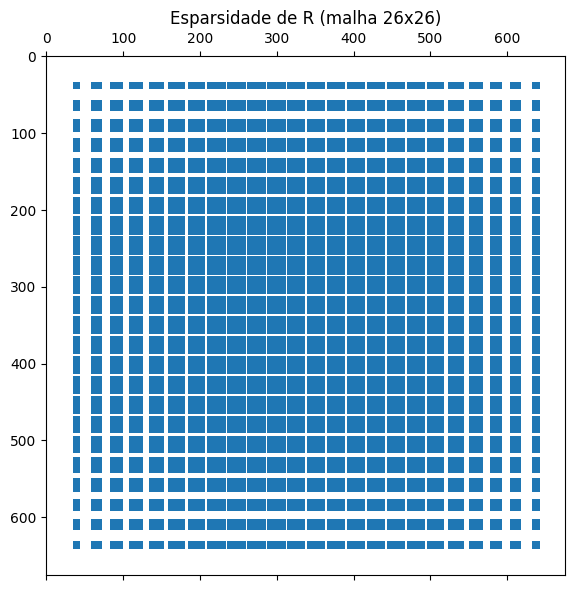

In [12]:
# Construção primária da rede para extrair A_net_sparse
Xno, conec = GeraGrafo(levels=complex_level)
Xno = Xno * mm_to_m
C = AssemblyVectorC(conec, Xno, H_k, mu)
A_net = Assembly(conec, C)
A_net_sparse = sparse.csr_matrix(A_net)
np_net = A_net_sparse.shape[0]

# Malha reduzida para visualização
N1_ex1, N2_ex1 = 26, 26
h_ad_ex1 = Lx_ad / (N1_ex1 - 1)

R_mat = Calcula_Matriz_R(
    A_net_sparse, N1_ex1, N2_ex1, Lx_ad, Ly_ad, R_ad, h_ad_ex1,
    sigma, rho, e_esp, R_fisico, n_inlet, n_outlet
)

n_nao_nulos = np.count_nonzero(R_mat)
print(f"Dimensão de R  : {R_mat.shape}")
print(f"Não nulos      : {n_nao_nulos}")
print(f"Densidade      : {n_nao_nulos / R_mat.size * 100:.1f} %")

plt.figure(figsize=(6, 6))
plt.spy(R_mat, marker=',', markersize=1)
plt.title(f"Esparsidade de R (malha {N1_ex1}x{N2_ex1})")
plt.tight_layout()
plt.show()


---
## Exercício 2 – Simulação Transiente Base
Nesta questão, analisamos o acoplamento hidromecânico entre a rede hidráulica e a membrana elástica. Para isso, fizemos a evolução temporal do sistema no intervalo adimensional de 0 a 12, observando o comportamento da deflexão da membrana, pressão no outlet, vazão no outlet, volume acumulado e potência hidráulica.

Também comparamos as malhas 51x51 e 101x101 para avaliar se o refinamento espacial da membrana altera significativamente os resultados globais.

Além disso, avaliamos a influência do passo de tempo, usando dt = 0.00625, 0.0125, 0.025 e 0.05, para verificar se a solução converge conforme o tempo é refinado.

Depois, estudamos a sensibilidade à pressão de entrada, variando p_inlet entre 5000, 10000 e 20000 Pa, analisando seu efeito sobre deslocamento, pressão, vazão e potência.

Por fim, analisamos a sensibilidade à largura dos canais, variando H entre 1000, 1250, 1500 e 1750 µm, para entender como a resistência hidráulica influencia a resposta do sistema.

---
## Exercício 3 – Análise de Sensibilidade ao Pulso de Pressão
A simulação do Exercício 3 analisou o comportamento do dispositivo microfluídico durante um ciclo de carga e descarga no tempo. Na fase de carregamento ($t < 12$), injetou-se uma pressão constante na entrada do sistema. Isso fez com que a membrana inflasse e o volume do reservatório aumentasse de forma suave e amortecida, devido ao equilíbrio entre a força do fluido nos microcanais e a resistência elástica da estrutura. A vazão e a potência hidráulica atingiram valores máximos no início para vencer a inércia do sistema, estabilizando-se logo em seguida.

No instante de corte ($t = 12$), a pressão de entrada foi zerada e a potência caiu para zero, iniciando a fase de relaxamento. Sem força externa, a membrana deformada agiu como um pistão elástico, espremendo o reservatório e expulsando o fluido de volta para a rede. Esse efeito de refluxo (\textit{backflow}) fez com que a vazão de saída ficasse negativa e a pressão sofresse uma queda brusca. Com o tempo, o tanque esvaziou por completo e a membrana retornou ao seu estado plano original, comprovando a estabilidade e a conservação de massa do modelo desenvolvido.

--- Iniciando Exercício 3: Relaxamento Transiente (Corte de Pressão) ---
Simulação concluída. Renderizando gráficos...


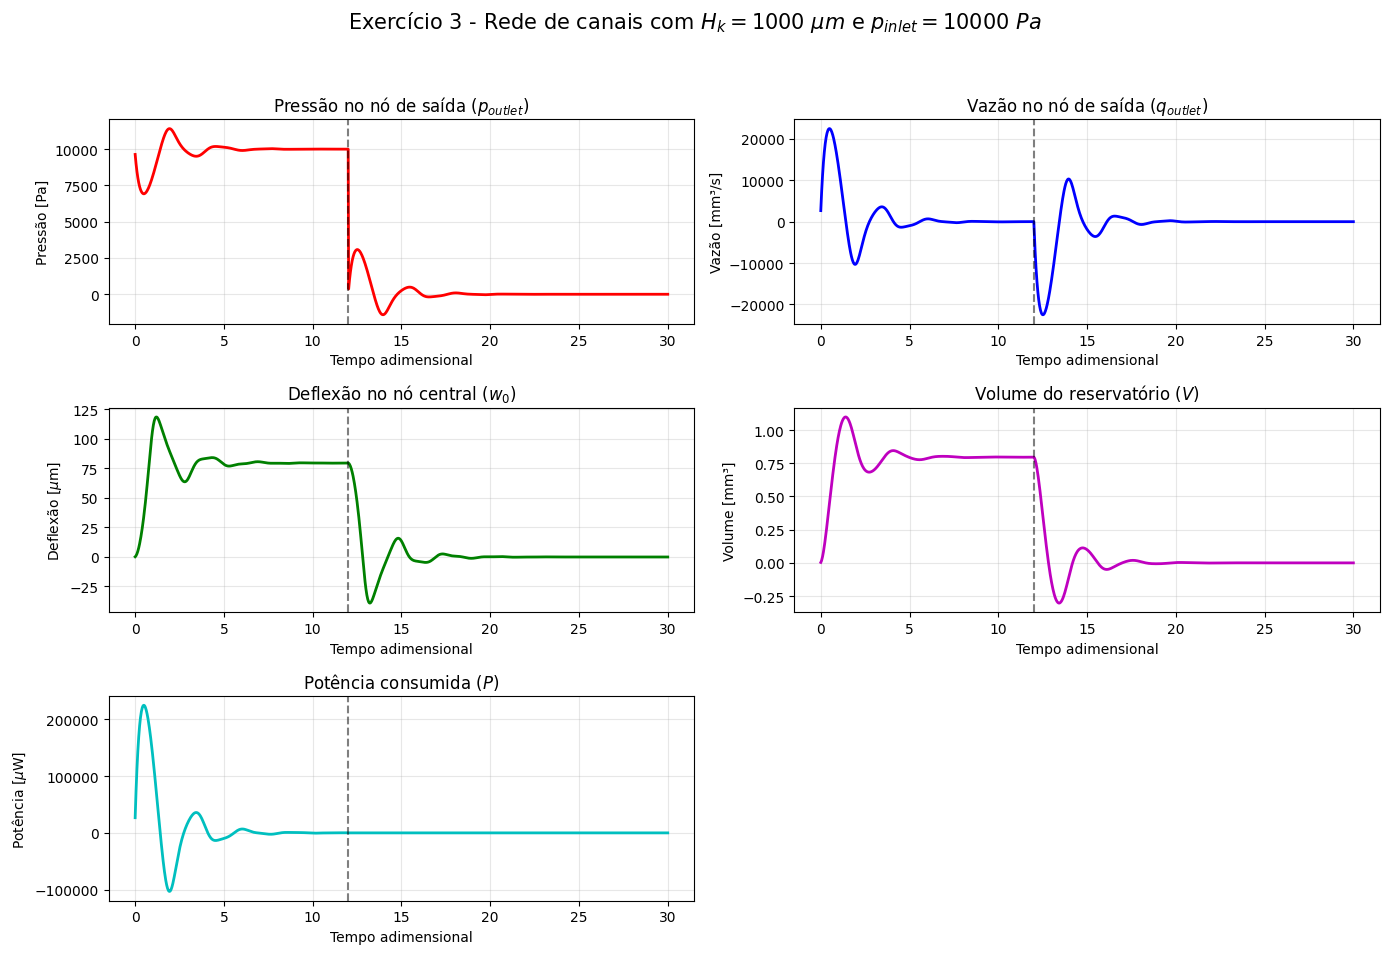

In [13]:
roda_exercicio_3()

---
## Exercício 4 – Variação do Nível de Complexidade da Rede
Nesta simulação, investigamos a resposta da membrana oscilando livremente a partir do seu 3º modo fundamental. Para isolar o efeito do acoplamento, zeramos a pressão da bomba, removemos o amortecimento do material elástico e alargamos os canais.

O gráfico abaixo mostra o decaimento do deslocamento no centro da membrana. A partir dele, extraímos uma frequência de oscilação simulada de 11349,82 Hz, em contraste com os 11384,89 Hz teóricos da membrana isolada.

Esse comportamento atesta o sucesso do acoplamento mecânico-hidráulico: a diferença de frequência ocorre devido à "massa adicional" imposta pela presença da água, e a perda de amplitude ao longo do tempo reflete o amortecimento hidráulico — a energia que a membrana gasta para forçar o fluido a escoar pela rede de microcanais.

In [ ]:
roda_exercicio_4(
    Nx, Ny, h_ad, dt, mu, R_fisico, e_esp, sigma, rho, 
    Lx_ad, Ly_ad, R_ad, sigma_ad, rho_ad, e_ad
)

---
## Exercício 5: Análise de Forçamento Harmônico e Ortogonalidade Espacial

Neste exercício, analisamos o acoplamento entre a rede hidráulica e a membrana elástica do reservatório. A ideia foi acompanhar a evolução temporal do sistema e observar como a pressão de entrada, a geometria dos canais e a discretização da membrana influenciam a resposta global.

No modelo, a rede hidráulica fornece a pressão e a vazão que atuam sobre a membrana, enquanto a deformação da membrana altera o volume do reservatório e retroage sobre o escoamento. Por isso, o problema precisa ser resolvido de forma acoplada, atualizando a cada passo de tempo as variáveis hidráulicas e mecânicas.

Primeiro, avaliamos o caso base e observamos a evolução de grandezas como deslocamento no centro da membrana, pressão no outlet, vazão de saída, volume acumulado e potência hidráulica. Depois, comparamos malhas diferentes para verificar se o refinamento espacial muda significativamente os resultados, e também testamos diferentes passos de tempo para checar a estabilidade e a convergência da solução.

O principal resultado é que o comportamento do sistema depende fortemente do equilíbrio entre a entrada de fluido e a deformação da membrana. Quando a pressão de entrada aumenta, a membrana se deforma mais, o volume interno cresce e a potência hidráulica necessária também sobe. Assim, o exercício mostra de forma clara como o acoplamento fluido-estrutura modifica a dinâmica do dispositivo e por que a modelagem numérica é essencial nesse tipo de problema.

In [ ]:
roda_exercicio_5(
    Nx, Ny, h_ad, dt, mu, R_fisico, e_esp, sigma, rho, 
    Lx_ad, Ly_ad, R_ad, sigma_ad, rho_ad, e_ad
)